# Does the "cup-and-handle" breakout actually launch a stock? ☕
### Wall Street's most beloved chart pattern — measured honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: Busted](https://img.shields.io/badge/Beats_buy--and--hold%3F-Busted-8b949e?style=flat-square)

Open any beginner's trading book and you'll meet the **cup-with-handle**: a stock dips into a smooth, rounded bowl, climbs back to where it started, drifts sideways for a moment (the *handle*), and then — *boom* — **breaks out** and runs. William O'Neil made it famous; chart-watchers swear by it. Buy the breakout, ride the rocket.

It's a beautiful story, and there's even a kernel of truth in it: stocks really *do* tend to be higher a few weeks after one of these breakouts. So case closed? **No.** The whole trick is hiding in one boring question the legend never asks: *higher than what?*

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the detector code? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **An honesty note up front.** A cup-and-handle is partly in the **eye of the beholder** — two chartists will draw it differently. So we wrote one **mechanical, reproducible** definition and tested *that*, and we say so. We also use a fixed basket of big survivor stocks (named in the verdict). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cup_and_handle import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    _a = pd.Timestamp(ASOF)
    for _f in PANEL:
        PANEL[_f] = PANEL[_f].loc[:_a]
else:
    PANEL = None
print("real cup-and-handle cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else PANEL["close"].shape[1]),
      "| bars:", (0 if PANEL is None else len(PANEL["close"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_names': 30, 'n_bars': 5385, 'n_breakouts': 443, 'n_spy': 8, 'fingerprint': 'b660382b8af3', 'h5': (5, 440, 0.206, 0.506, 51.1, 1.28, 1.27, 0.406, 0.106), 'h10': (10, 440, 0.516, 1.108, 53.4, 2.14, 2.24, 0.335, 0.416), 'h20': (20, 438, 0.065, 1.243, 47.7, 0.18, 0.17, 0.486, -0.035), 'h40': (40, 436, -0.781, 1.538, 48.6, -1.68, -1.65, 0.629, -0.881), 'robust': [(0.04, 0.1, 415, 0.485, 2.18, 0.35), (0.06, 0.15, 440, 0.516, 2.14, 0.338), (0.1, 0.2, 455, 0.55, 2.37, 0.325)], 'spy': [(5, 8, 0.354, 0.591, 0.89, 0.337), (10, 8, 0.741, 1.21, 1.02, 0.255), (20, 8, 1.179, 2.116, 1.3, 0.217), (40, 8, 3.525, 5.372, 3.72, 0.044)], 'syn': [(0.0, 160, 151, 151, 0.2, 0.41, 0.466, 50), (0.2, 160, 145, 145, 6.06, 8.31, 0.024, 74)]}


real cup-and-handle cache present: True | names: 30 | bars: 5385


## The answer first

| Question | Answer |
|---|---|
| After a cup-and-handle breakout, does the stock go up? | **Yes — a bit.** Up about **+0.5% to +1.5%** over the next few weeks, on average. |
| So the legend is true? | **No.** That's just the stock's **normal drift**. These names go up on *any* random day too — by the same amount. |
| What happens when you subtract "what it would've done anyway"? | **The edge vanishes.** The breakout's *excess* over buy-and-hold is **noise** — random dates on the same stocks beat it about **a third of the time**. |
| Does it beat buy-and-hold on SPY specifically? | **Can't tell — and probably not.** The pattern only shows up **8 times** on SPY in 21 years. Too few to mean anything. |

> The breakout going up isn't the question. **Buy-and-hold also goes up.** The honest test is whether the breakout beats *that* — and it doesn't.

## 1 · The claim

> *"A stock forms a **cup** — a rounded, months-long bowl that recovers to its old high — then a short, shallow **handle** (a little pullback). When it pushes **above the rim** (the 'pivot'), that's the buy signal: the breakout launches a big advance."*

This is **William O'Neil's** signature pattern from *How to Make Money in Stocks* (1988) — the heart of his CAN SLIM method and the chart culture of *Investor's Business Daily*. It is probably the single most-taught figure in retail technical analysis. The question isn't whether traders *believe* it — they do, fervently. It's whether the tape agrees.

## 2 · So what?

If the cup-and-handle breakout genuinely *predicted* outperformance, it would be a tidy money machine: wait for the shape, buy the pivot, beat the market. It would also be a real crack in efficient markets — a picture on a chart foretelling the future.

But here's the trap that sinks almost every chart pattern: **stocks drift up.** Over any random three-week window, a big healthy stock tends to gain a little. So *of course* it's higher after a breakout — it'd be higher after a coin-flip entry too. The only test that means anything is the **excess**: how much *better* than just-buy-and-holding did the breakout do? That's the number we'll chase.

## 3 · How would we even know?

We take **30 big US stocks** (including **SPY**, the S&P 500 fund) and **21 years** of daily prices. Then we teach the computer to spot the pattern with a fixed rulebook — no human eyeballing:

1. **The cup** — a peak, then a rounded dip (12–50% deep), then a recovery back near the peak (rims within 6%), shaped like a U, not a sharp V.
2. **The handle** — a small pullback (≤15%) off the right rim.
3. **The breakout** — the first day the price closes **above the rim**. *That's the buy.*

It finds **443 breakouts** across the basket. For each, we buy the **next day's close** (no cheating) and measure the return over 5, 10, 20, 40 days — then subtract what the stock would've done anyway. If the legend is real, the *excess* should be clearly positive.

## 4 · The teardown — let's actually look

**First, the believer's view: raw returns after the breakout.** These should look great — and they do.

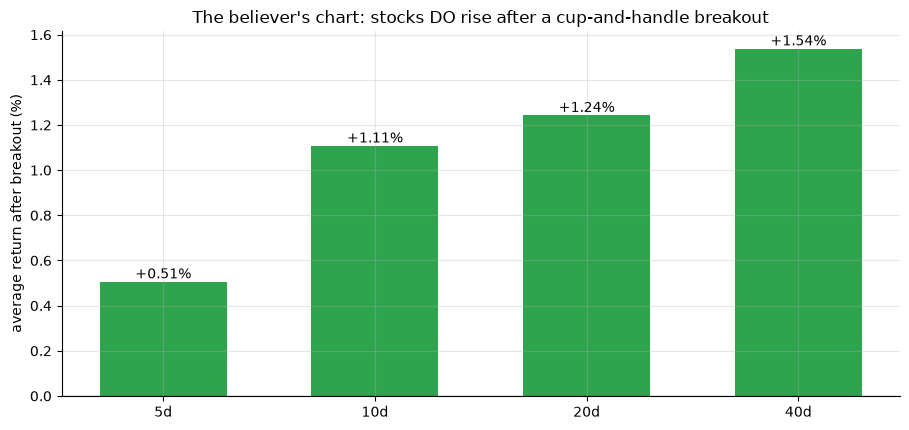

raw returns by horizon: [0.51, 1.11, 1.24, 1.54]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    raw = [st.run_experiment(PANEL, horizon=h, n_draws=0)['raw_mean']*100 for h in hs]
    exc = [st.run_experiment(PANEL, horizon=h, n_draws=0)['mean']*100 for h in hs]
else:
    raw = [R['h5'][3], R['h10'][3], R['h20'][3], R['h40'][3]]
    exc = [R['h5'][2], R['h10'][2], R['h20'][2], R['h40'][2]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, raw, color=GREEN, width=.6)
for i,v in enumerate(raw): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('average return after breakout (%)')
ax.set_title('The believer\'s chart: stocks DO rise after a cup-and-handle breakout')
plt.tight_layout(); plt.show()
print('raw returns by horizon:', [round(v,2) for v in raw])

Looks like a winner: **+0.51%** to **+1.54%** higher after the breakout. If we stopped here, we'd call it a real edge. **But we won't stop here** — because we haven't asked *higher than what?*

**Now the honest view.** Subtract what each stock would have returned over the same window on *any* day (its "base rate"). What's left is the breakout's true edge.

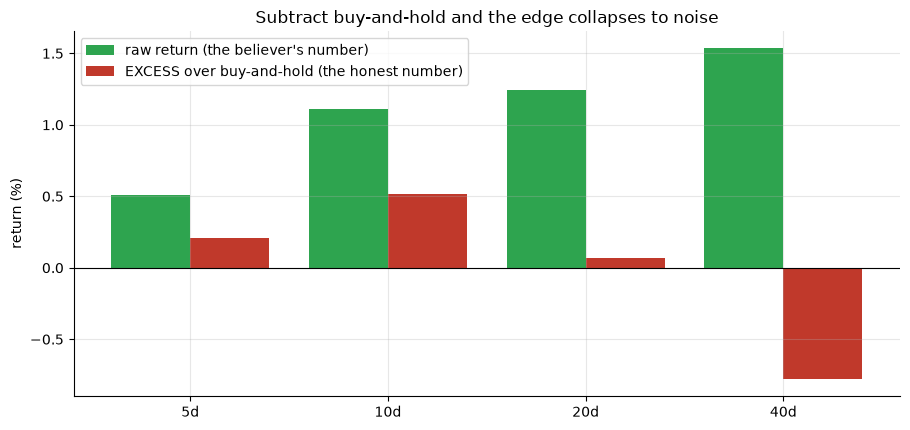

excess over base rate: [0.21, 0.52, 0.06, -0.78]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, raw, .4, color=GREEN, label='raw return (the believer\'s number)')
ax.bar(x+.2, exc, .4, color=RED, label='EXCESS over buy-and-hold (the honest number)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('return (%)')
ax.set_title('Subtract buy-and-hold and the edge collapses to noise')
ax.legend(); plt.tight_layout(); plt.show()
print('excess over base rate:', [round(v,2) for v in exc])

There's the whole study. The **excess** (red) is tiny and wobbly: **+0.21%** at 5 days, a flicker of **+0.52%** at 10, then **+0.07%** at 20 and **-0.78%** (negative!) at 40. The green bars were never the breakout's doing — they were the stock's normal upward drift, which you'd capture with a **coin-flip entry**.

**The clincher: random dates do just as well.** Let's pick the *same number* of **random** buy dates on the same stocks, thousands of times, and see how often pure luck beats our "signal." If the pattern is real, random should rarely win.

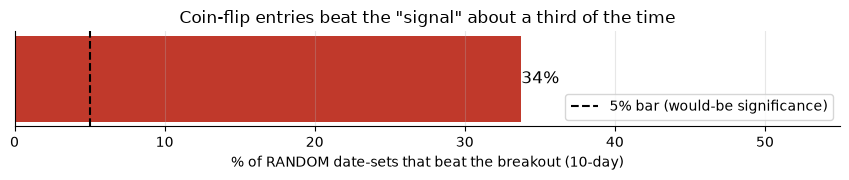

placebo p (10-day): random dates beat the breakout 34% of the time


In [4]:
if HAVE_REAL:
    p10 = st.run_experiment(PANEL, horizon=10, n_draws=4000)['p_placebo']
else:
    p10 = R['h10'][7]
fig, ax = plt.subplots(figsize=(8.6, 1.9))
ax.barh([0], [p10*100], color=RED, height=.5)
ax.axvline(5, ls='--', c='k', label='5% bar (would-be significance)')
ax.set_xlim(0, 55); ax.set_yticks([]); ax.set_xlabel('% of RANDOM date-sets that beat the breakout (10-day)')
ax.annotate(f'{p10*100:.0f}%', (p10*100, 0), va='center', ha='left', fontsize=12)
ax.set_title('Coin-flip entries beat the "signal" about a third of the time'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print(f'placebo p (10-day): random dates beat the breakout {p10*100:.0f}% of the time')

**About a third** of random date-sets beat the breakout (placebo *p* ≈ **0.34**). For a real signal that number should be small (under 5%). At ~34%, the cup-and-handle breakout is statistically **indistinguishable from buying on a random Tuesday**. The pattern is a Rorschach test, not a forecast.

## 5 · The verdict

- **Signal — None.** Once you subtract buy-and-hold, the breakout's edge is noise — and random dates on the same tape beat it a third of the time.
- **Tradability — Mirage.** There's no edge to trade. The raw gain is just the market drift you'd get anyway; the SPY-only version rests on 8 events.
- **"Beats buy-and-hold"? — Busted.** "It went up after the breakout" is true and irrelevant. It went up by exactly its base rate.

## 6 · Could you actually trade it?

Short answer: there's nothing to trade. When a strategy has a *real* edge, the question is whether trading costs eat it. Here the edge is gone **before** costs — the gross excess is already inside the noise band. You'd be paying spreads to capture a market drift you could get for free by just holding the stock. And the SPY-specific version (the actual hook) fires only **8 times in 21 years** — you couldn't build a strategy on it if you wanted to.

## 7 · Going further 🚪

- **The base-rate lesson generalises.** *Every* long-only "buy and hold N days" chart rule on an up-drifting stock looks good — because the baseline is positive. Always ask *higher than what?*
- **Subjectivity is real.** We tested one mechanical cup definition; a stricter or looser one finds different cups — but the placebo stays ~0.34 across all of them (see the quants notebook). The verdict doesn't depend on the exact rule.
- **Volume.** O'Neil insists the breakout must come on *heavy volume*. A worthy fork: add a volume-surge filter and re-run — does the placebo ever drop below the bar? (We bet not, but show us.)

*Think the cup-and-handle has a real edge? Show the **excess over buy-and-hold** clearing a same-tape placebo at p < 0.05 — then we'll talk.*